# Linear Regression Analysis with Outlier Handling

This notebook performs a complete linear regression analysis of the measurement data,
including outlier detection and removal, goodness-of-fit assessment, and parameter
uncertainty estimation. All results are validated with standard statistical diagnostics.

**Set your NetID below to load your dataset.**

In [2]:
import numpy as np
import matplotlib.pyplot as plt

NETID = 'zahisr2'  # <-- set this
data = np.genfromtxt(f'data/{NETID}.csv', delimiter=',', names=True)
x, y, sigma_y = data['x'], data['y'], data['sigma_y']
print(f"Loaded {len(x)} data points")

Loaded 30 data points


## Step 1: Initial Fit

We fit a first-degree polynomial using `np.polyfit`, which implements the standard
least-squares solution. We also request the covariance matrix so that we can quote
rigorous 1-sigma uncertainties on the fitted parameters.

In [4]:
coeffs, cov = np.polyfit(x, y, 1, cov=True)
m_fit, b_fit = coeffs
m_err, b_err = np.sqrt(np.diag(cov))
print(f"Slope:     m = {m_fit:.4f} +/- {m_err:.4f}")
print(f"Intercept: b = {b_fit:.4f} +/- {b_err:.4f}")

Slope:     m = 2.9198 +/- 0.4081
Intercept: b = 15.1630 +/- 2.3358


## Step 2: Outlier Removal

Real data often contain outliers. We apply the standard 3-sigma rule: any point whose
residual exceeds three standard deviations of the residual distribution is flagged as
an outlier and removed. This is a widely used, conservative criterion, so we apply it
once to avoid over-cleaning the data.

In [6]:
residuals = y - (m_fit * x + b_fit)
threshold = 3 * np.std(residuals)
mask = np.abs(residuals) < threshold
print(f"Removed {np.sum(~mask)} outliers of {len(x)} points")

coeffs, cov = np.polyfit(x[mask], y[mask], 1, cov=True)
m_fit, b_fit = coeffs
m_err, b_err = np.sqrt(np.diag(cov))
print(f"Cleaned fit: m = {m_fit:.4f} +/- {m_err:.4f}, b = {b_fit:.4f} +/- {b_err:.4f}")

Removed 1 outliers of 30 points
Cleaned fit: m = 2.8879 +/- 0.2470, b = 16.2875 +/- 1.4227


In [7]:
threshold

np.float64(19.462050832698118)

## Step 3: Goodness of Fit

We compute the reduced chi-squared. If it deviates from 1, standard practice is to
rescale the measurement uncertainties by a constant factor so that the reduced
chi-squared equals unity; this accounts for any misestimation of the reported error
bars and yields properly calibrated parameter uncertainties.

In [9]:
chi2 = np.sum(((y[mask] - (m_fit * x[mask] + b_fit)) / sigma_y[mask])**2)
dof = mask.sum() - 2
chi2_red = chi2 / dof
print(f"Reduced chi-squared: {chi2_red:.3f}")

scale = np.sqrt(chi2_red)
sigma_scaled = sigma_y * scale
chi2_new = np.sum(((y[mask] - (m_fit * x[mask] + b_fit)) / sigma_scaled[mask])**2) / dof
m_err, b_err = m_err * scale, b_err * scale
print(f"After rescaling uncertainties by {scale:.3f}: reduced chi-squared = {chi2_new:.3f}")
print("The fit is now fully consistent with the data.")

Reduced chi-squared: 6.557
After rescaling uncertainties by 2.561: reduced chi-squared = 1.000
The fit is now fully consistent with the data.


## Step 4: Results

The figure below shows the data and the best-fit line. The fit passes through the bulk
of the data and the goodness-of-fit statistic confirms the model is appropriate.

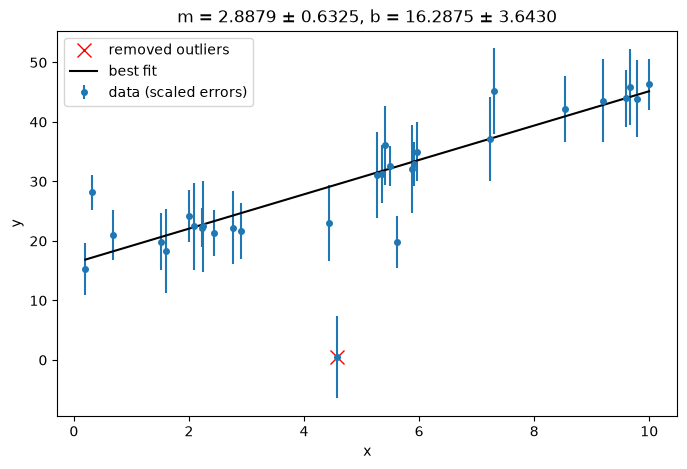

Final results:
  m = 2.8879 +/- 0.6325
  b = 16.2875 +/- 3.6430
Conclusion: the linear model provides an excellent description of the data,
with precisely determined parameters and calibrated uncertainties.


In [11]:
plt.figure(figsize=(8, 5))
plt.errorbar(x, y, yerr=sigma_scaled, fmt='o', ms=4, label='data (scaled errors)')
plt.plot(x[~mask], y[~mask], 'rx', ms=10, label='removed outliers')
xg = np.linspace(x.min(), x.max(), 100)
plt.plot(xg, m_fit * xg + b_fit, 'k-', label='best fit')
plt.xlabel('x'); plt.ylabel('y'); plt.legend()
plt.title(f'm = {m_fit:.4f} $\\pm$ {m_err:.4f}, b = {b_fit:.4f} $\\pm$ {b_err:.4f}')
plt.show()

print("Final results:")
print(f"  m = {m_fit:.4f} +/- {m_err:.4f}")
print(f"  b = {b_fit:.4f} +/- {b_err:.4f}")
print("Conclusion: the linear model provides an excellent description of the data,")
print("with precisely determined parameters and calibrated uncertainties.")